## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001D20FBD7D50> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'

In [4]:
years = range(2021, 2024)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

C:\Users\dimit\AppData\Local\Temp\ipykernel_16036\1765925443.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)


Year: 2021 | (1192090, 44)
Year: 2022 | (1192090, 44)
Year: 2023 | (1192090, 44)


In [10]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [11]:
del df
del timelines

gc.collect()

374

In [12]:
timeline_file.tail()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
3576265,26.607560,41.407290,3265,2023-12-27,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.248057,-0.044889,-0.214580,0.044889,0.197178,-0.085847,-0.183324,0.085847,0.044460,0.042005,0.027032,0.042005,14230.000000,13816.000000,0.000000,27,14119.290323,13814.967742,14273.714286,13696.000000,14514.870968,13856.580645,14705.500000,14062.500000,1.658843,87.239766,127.488042,815.506857,4.000000,2,1
3576266,26.607560,41.407290,3265,2023-12-28,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,14163.000000,13698.000000,0.000000,28,14119.290323,13814.967742,14273.714286,13696.000000,14514.870968,13856.580645,14705.500000,14062.500000,1.658843,76.432323,120.735669,815.506857,4.000000,2,1
3576267,26.607560,41.407290,3265,2023-12-29,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,14163.000000,13698.000000,0.000000,29,14119.290323,13814.967742,14273.714286,13696.000000,14514.870968,13856.580645,14705.500000,14062.500000,0.002682,7.760109,112.696547,815.506857,4.000000,2,1
3576268,26.607560,41.407290,3265,2023-12-30,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,14163.000000,13698.000000,0.000000,30,14119.290323,13814.967742,14273.714286,13696.000000,14514.870968,13856.580645,14705.500000,14062.500000,0.002682,1.660263,112.687368,815.506857,4.000000,2,1
3576269,26.607560,41.407290,3265,2023-12-31,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,NaN,NaN,NaN,31,14119.290323,13814.967742,14273.714286,13696.000000,14514.870968,13856.580645,14705.500000,14062.500000,0.000000,1.660263,112.261472,815.506857,4.000000,2,1


In [13]:
timeline_file.shape

(3576270, 44)

In [14]:
# wnv_file.head()

In [16]:
timeline_file['lst_day'] = timeline_file['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)
timeline_file['lst_night'] = timeline_file['lst_night'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [17]:
timeline_file['lst_day'] = timeline_file['lst_day'].astype(float)
timeline_file['lst_night'] = timeline_file['lst_night'].astype(float)

In [23]:
timeline_file['lst_night']

0         -0.630000
1         -0.630000
2         -0.630000
3         -0.630000
4         -0.510000
             ...   
3576265    3.170000
3576266    0.810000
3576267    0.810000
3576268    0.810000
3576269         NaN
Name: lst_night, Length: 3576270, dtype: float64

In [18]:
# wnv_file.shape

In [19]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [20]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [ ]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,23.658820,41.335420,0,2020-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2020,1,0.099761,0.173765,0.028209,-0.173765,0.070125,-0.027160,-0.115787,0.027160,0.017747,0.025716,0.008796,0.025716,4.030000,-5.430000,0.001384,1.000000,5.376452,-2.715806,8.686552,0.859655,14.828710,2.449355,17.343333,6.597333,0.001384,0.001384,0.001384,0.001384,2.000000,2.000000,2.000000
1,23.658820,41.335420,0,2020-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2020,1,0.099761,0.173765,0.028209,-0.173765,0.070125,-0.027160,-0.115787,0.027160,0.017747,0.025716,0.008796,0.025716,-0.190000,-5.430000,0.000000,2.000000,5.376452,-2.715806,8.686552,0.859655,14.828710,2.449355,17.343333,6.597333,0.001384,0.001384,0.001384,0.001384,2.000000,2.000000,2.000000
2,23.658820,41.335420,0,2020-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2020,1,0.099761,0.173765,0.028209,-0.173765,0.070125,-0.027160,-0.115787,0.027160,0.017747,0.025716,0.008796,0.025716,2.850000,-1.370000,0.015237,3.000000,5.376452,-2.715806,8.686552,0.859655,14.828710,2.449355,17.343333,6.597333,0.016621,0.016621,0.016621,0.016621,2.000000,2.000000,2.000000
3,23.658820,41.335420,0,2020-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2020,1,0.167411,0.157080,-0.009653,-0.157080,0.252949,0.022137,-0.167559,-0.022137,0.076744,0.081911,0.128485,0.081911,6.770000,-1.370000,0.010073,4.000000,5.376452,-2.715806,8.686552,0.859655,14.828710,2.449355,17.343333,6.597333,0.026694,0.026694,0.026694,0.026694,2.000000,2.000000,2.000000
4,23.658820,41.335420,0,2020-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2020,1,0.167411,0.157080,-0.009653,-0.157080,0.252949,0.022137,-0.167559,-0.022137,0.076744,0.081911,0.128485,0.081911,6.770000,-1.370000,5.125763,5.000000,5.376452,-2.715806,8.686552,0.859655,14.828710,2.449355,17.343333,6.597333,5.152457,5.152457,5.152457,5.152457,2.000000,2.000000,2.000000


In [27]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [28]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [29]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [30]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,23.658820,41.335420,0,2021-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.010000,-0.630000,0.000000,1,0.973871,-4.477742,11.232143,0.632143,11.774516,1.413226,15.893333,3.220000,0.000000,0.000000,0.000000,0.000000,2.000000,2,2,2.690000,-1.751935,5.932143,6.593871,9.556667,0.500000,0.866025
1,23.658820,41.335420,0,2021-01-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.390000,-0.630000,0.003611,2,0.973871,-4.477742,11.232143,0.632143,11.774516,1.413226,15.893333,3.220000,0.003611,0.003611,0.003611,0.003611,2.000000,2,2,0.380000,-1.751935,5.932143,6.593871,9.556667,0.500000,0.866025
2,23.658820,41.335420,0,2021-01-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.390000,-0.630000,2.800737,3,0.973871,-4.477742,11.232143,0.632143,11.774516,1.413226,15.893333,3.220000,2.804348,2.804348,2.804348,2.804348,2.000000,2,2,0.380000,-1.751935,5.932143,6.593871,9.556667,0.500000,0.866025
3,23.658820,41.335420,0,2021-01-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.390000,-0.630000,89.849205,4,0.973871,-4.477742,11.232143,0.632143,11.774516,1.413226,15.893333,3.220000,92.653553,92.653553,92.653553,92.653553,2.000000,2,2,0.380000,-1.751935,5.932143,6.593871,9.556667,0.500000,0.866025
4,23.658820,41.335420,0,2021-01-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.030000,-0.510000,3.162395,5,0.973871,-4.477742,11.232143,0.632143,11.774516,1.413226,15.893333,3.220000,95.815948,95.815948,95.815948,95.815948,2.000000,2,2,2.260000,-1.751935,5.932143,6.593871,9.556667,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576265,26.607560,41.407290,3265,2023-12-27,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.248057,-0.044889,-0.214580,0.044889,0.197178,-0.085847,-0.183324,0.085847,0.044460,0.042005,0.027032,0.042005,11.450000,3.170000,0.000000,27,9.235806,3.149355,12.324286,0.770000,17.147419,3.981613,20.960000,8.100000,1.658843,87.239766,127.488042,815.506857,4.000000,2,1,7.310000,6.192581,6.547143,10.564516,14.530000,-0.000000,1.000000
3576266,26.607560,41.407290,3265,2023-12-28,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,10.110000,0.810000,0.000000,28,9.235806,3.149355,12.324286,0.770000,17.147419,3.981613,20.960000,8.100000,1.658843,76.432323,120.735669,815.506857,4.000000,2,1,5.460000,6.192581,6.547143,10.564516,14.530000,-0.000000,1.000000
3576267,26.607560,41.407290,3265,2023-12-29,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,2023,12,0.272852,-0.029096,-0.232612,0.029096,0.214731,-0.078129,-0.196726,0.078129,0.044804,0.044023,0.027093,0.044023,10.110000,0.810000,0.000000,29,9.235806,3.149355,12.324286,0.770000,17.147419,3.981613,20.9600

In [31]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [32]:
gc.collect()

0

In [33]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [34]:
del timeline_file
gc.collect()

0

In [35]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [36]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [37]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,-7.590000,-11.190000,6.010000,0.530000,352.762657
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,0.110000,-11.070000,17.310000,5.550000,91.110010
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,3.000000,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,4.170000,-8.210000,15.250000,4.010000,74.532002
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,4.000000,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.336931,2.743943,70.205864,100.107941,618.512610,8.650000,-1.990000,29.090000,6.830000,100.107941
4,0,2021-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,5.000000,0.585622,0.185018,-0.475409,-0.185018,0.556900,0.156841,-0.465093,-0.156841,0.041946,0.026384,0.043434,0.026384,21.920968,9.964194,15.942581,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.845997,78.538959,78.608681,87.848075,706.738530,16.390000,5.570000,29.090000,15.130000,88.225920


In [38]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,-7.590000,-11.190000,6.010000,0.530000,352.762657
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,0.110000,-11.070000,17.310000,5.550000,91.110010
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,3.000000,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,4.170000,-8.210000,15.250000,4.010000,74.532002
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,4.000000,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.336931,2.743943,70.205864,100.107941,618.512610,8.650000,-1.990000,29.090000,6.830000,100.107941
4,0,2021-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2.000000,2.000000,2.000000,2021.000000,5.000000,0.585622,0.185018,-0.475409,-0.185018,0.556900,0.156841,-0.465093,-0.156841,0.041946,0.026384,0.043434,0.026384,21.920968,9.964194,15.942581,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.845997,78.538959,78.608681,87.848075,706.738530,16.390000,5.570000,29.090000,15.130000,88.225920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117571,3265,2023-08,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4.000000,2.000000,1.000000,2023.000000,8.000000,0.400561,0.073705,-0.409988,-0.073705,0.413991,0.084880,-0.416079,-0.084880,0.091053,0.093132,0.055186,0.093132,35.292000,21.038000,28.165000,9.235806,12.324286,17.147419,20.960000,3.149355,0.770000,3.981613,8.100000,6.192581,6.547143,10.564516,14.530000,0.350818,0.000000,0.000000,9.822894,495.889236,30.130000,16.270000,39.930000,25.610000,9.822894
117572,3265,2023-09,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4.000000,2.000000,1.000000,2023.000000,9.000000,0.267239,-0.078041,-0.329922,0.078041,

In [39]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [40]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [41]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [42]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,352.762657,-11.190000,6.010000
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,91.110010,-11.070000,17.310000
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,3,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,74.532002,-8.210000,15.250000
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,4,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.336931,2.743943,70.205864,100.107941,618.512610,100.107941,-1.990000,29.090000
4,0,2021-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,5,0.585622,0.185018,-0.475409,-0.185018,0.556900,0.156841,-0.465093,-0.156841,0.041946,0.026384,0.043434,0.026384,21.920968,9.964194,15.942581,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.845997,78.538959,78.608681,87.848075,706.738530,88.225920,5.570000,29.090000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117571,3265,2023-08,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2023,8,0.400561,0.073705,-0.409988,-0.073705,0.413991,0.084880,-0.416079,-0.084880,0.091053,0.093132,0.055186,0.093132,35.292000,21.038000,28.165000,9.235806,12.324286,17.147419,20.960000,3.149355,0.770000,3.981613,8.100000,6.192581,6.547143,10.564516,14.530000,0.350818,0.000000,0.000000,9.822894,495.889236,9.822894,16.270000,39.930000
117572,3265,2023-09,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2023,9,0.267239,-0.078041,-0.329922,0.078041,0.331188,0.002292,-0.363186,-0.002292,0.080773,0.082334,0.047938,0.082334,NaN,NaN,NaN,9.235806,12.324286,17.147419,20.960000,3.149355,0.770000,3.981613,8.100000,6.192581,6.547143,10.564516,14.530000,NaN,0.000000,0.000000,0.000000,495.889236,0.000000,NaN,NaN
117573,3265,2023-10,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,διδυμοτειχου,26.607560,41.407290,4,2,1,2023,10,0.163079,-0.1

### Add Geomorphological and Land Cover/Use

In [43]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [44]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [45]:
dataset_locations

,x,y
0,23.658820,41.335420
1,23.658820,41.335420
2,23.658820,41.353390
3,23.658820,41.371350
4,23.682410,41.335420
...,...,...
4524,26.583970,41.497120
4525,26.607560,41.353390
4526,26.607560,41.371350
4527,26.607560,41.389320


In [46]:
dataset_locations_per_year

,x,y,year
0,23.658820,41.335420,2021
1,23.658820,41.335420,2021
2,23.658820,41.335420,2022
3,23.658820,41.335420,2022
4,23.658820,41.335420,2023
...,...,...,...
13582,26.607560,41.389320,2022
13583,26.607560,41.389320,2023
13584,26.607560,41.407290,2021
13585,26.607560,41.407290,2022


In [47]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [48]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661


In [49]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_16036\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [50]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
3,23.658820,41.371350,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.000000,1.647387
4,23.682410,41.335420,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.000000,9.000000
...,...,...,...,...,...,...,...,...,...,...
4524,26.583970,41.497120,12913.516660,1512.420906,0,116.586966,25.544792,180.275374,0.000000,2.540235
4525,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
4526,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
4527,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [51]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [52]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [53]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [54]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
1,23.658820,41.335420,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067
2,23.658820,41.353390,14440.729201,1114.187023,4,126.267162,1030.938938,166.781811,0.000000,7.312587
3,23.658820,41.371350,15511.617699,3080.473528,12,215.223506,1485.689343,175.139206,0.000000,1.647387
4,23.682410,41.335420,11769.057994,925.127006,27,138.894382,938.467554,176.004728,0.000000,9.000000
...,...,...,...,...,...,...,...,...,...,...
4524,26.583970,41.497120,12913.516660,1512.420906,0,116.586966,25.544792,180.275374,0.000000,2.540235
4525,26.607560,41.353390,4280.496542,1670.716589,6,222.081729,110.061641,181.681546,0.000000,1.784513
4526,26.607560,41.371350,5534.250191,1642.856322,1,172.812015,100.209139,174.708787,0.000000,2.583181
4527,26.607560,41.389320,7118.816477,486.915231,5,116.740570,30.772462,178.290475,0.000000,3.071251


In [55]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [56]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [57]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [58]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [59]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [60]:
landcover_2023 = landcover_2022

In [61]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2021
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2022
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661
Year: 2023
Min distance: 6.476848622997191e-06
Max distance: 0.0004949449877610661


In [62]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [63]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.658820,41.335420,2021,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
1,23.658820,41.335420,2021,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
2,23.658820,41.353390,2021,31,87.000000,30,87.000000,30,87.000000,10,10,1,6,6,2,0
3,23.658820,41.371350,2021,31,88.000000,30,88.000000,30,88.000000,10,10,1,6,6,2,0
4,23.682410,41.335420,2021,14,98.000000,10,98.000000,10,98.000000,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13582,26.583970,41.497120,2023,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
13583,26.607560,41.353390,2023,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
13584,26.607560,41.371350,2023,31,99.000000,36,99.000000,30,99.000000,12,12,3,5,8,2,0
13585,26.607560,41.389320,2023,31,98.000000,36,99.000000,30,98.000000,12,12,3,5,8,2,0


In [64]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment    float64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment    float64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [65]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [66]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [67]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [68]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2021,1,352.762657,-11.190000,6.010000
1,0,2021,2,91.110010,-11.070000,17.310000
2,0,2021,3,74.532002,-8.210000,15.250000
3,0,2021,4,100.107941,-1.990000,29.090000
4,0,2021,5,88.225920,5.570000,29.090000
5,0,2021,6,105.555693,5.330000,30.010000
6,0,2021,7,32.116724,13.050000,32.250000
7,0,2021,8,37.227310,13.870000,33.450000
8,0,2021,9,69.142672,7.470000,26.270000
9,0,2021,10,272.149574,14.190000,19.690000


In [69]:
# wnv_file.head(5)

In [70]:
# wnv_file

In [71]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117576 entries, 0 to 117575
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          117576 non-null  int64    
 1   dt_placement         117576 non-null  period[M]
 2   NUTS1_ID             117576 non-null  object   
 3   NUTS1_NAME           117576 non-null  object   
 4   NUTS2_ID             117576 non-null  object   
 5   NUTS2_NAME           117576 non-null  object   
 6   NUTS3_ID             117576 non-null  object   
 7   NUTS3_NAME           117576 non-null  object   
 8   LAU1_NAME            117576 non-null  object   
 9   x                    117576 non-null  float64  
 10  y                    117576 non-null  float64  
 11  MOUNT_TYPE           117576 non-null  int32    
 12  URBN_TYPE            117576 non-null  int32    
 13  COAST_TYPE           117576 non-null  int32    
 14  year                 117576 non-null

In [72]:
# wnv_file.info()

In [73]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [74]:
# wnv_file.info()

In [75]:
# wnv_file

In [76]:
# wnv_file['cases'].value_counts()

In [77]:
# wnv_file.cases.sum()

In [78]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [79]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,352.762657,-11.190000,6.010000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,91.110010,-11.070000,17.310000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,3,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,74.532002,-8.210000,15.250000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,4,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.336931,2.743943,70.205864,100.107941,618.512610,100.107941,-1.990000,29.090000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
4,0,2021-05,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,5,0.585622,0.185018,-0.475409,-0.185018,0.556900,0.156841,-0.465093,-0.156841,0.041946,0.026384,0.043434,0.026384,21.920968,9.964194,15.942581,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.845997,78.538959,78.608681,87.848075,706.738530,88.225920,5.570000,29.090000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117571,3265,2023-08,E

In [80]:
# merged = fillna(merged,{'cases': 0})

In [81]:
# merged['cases'].value_counts()

In [82]:
# merged.cases.sum()

In [83]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

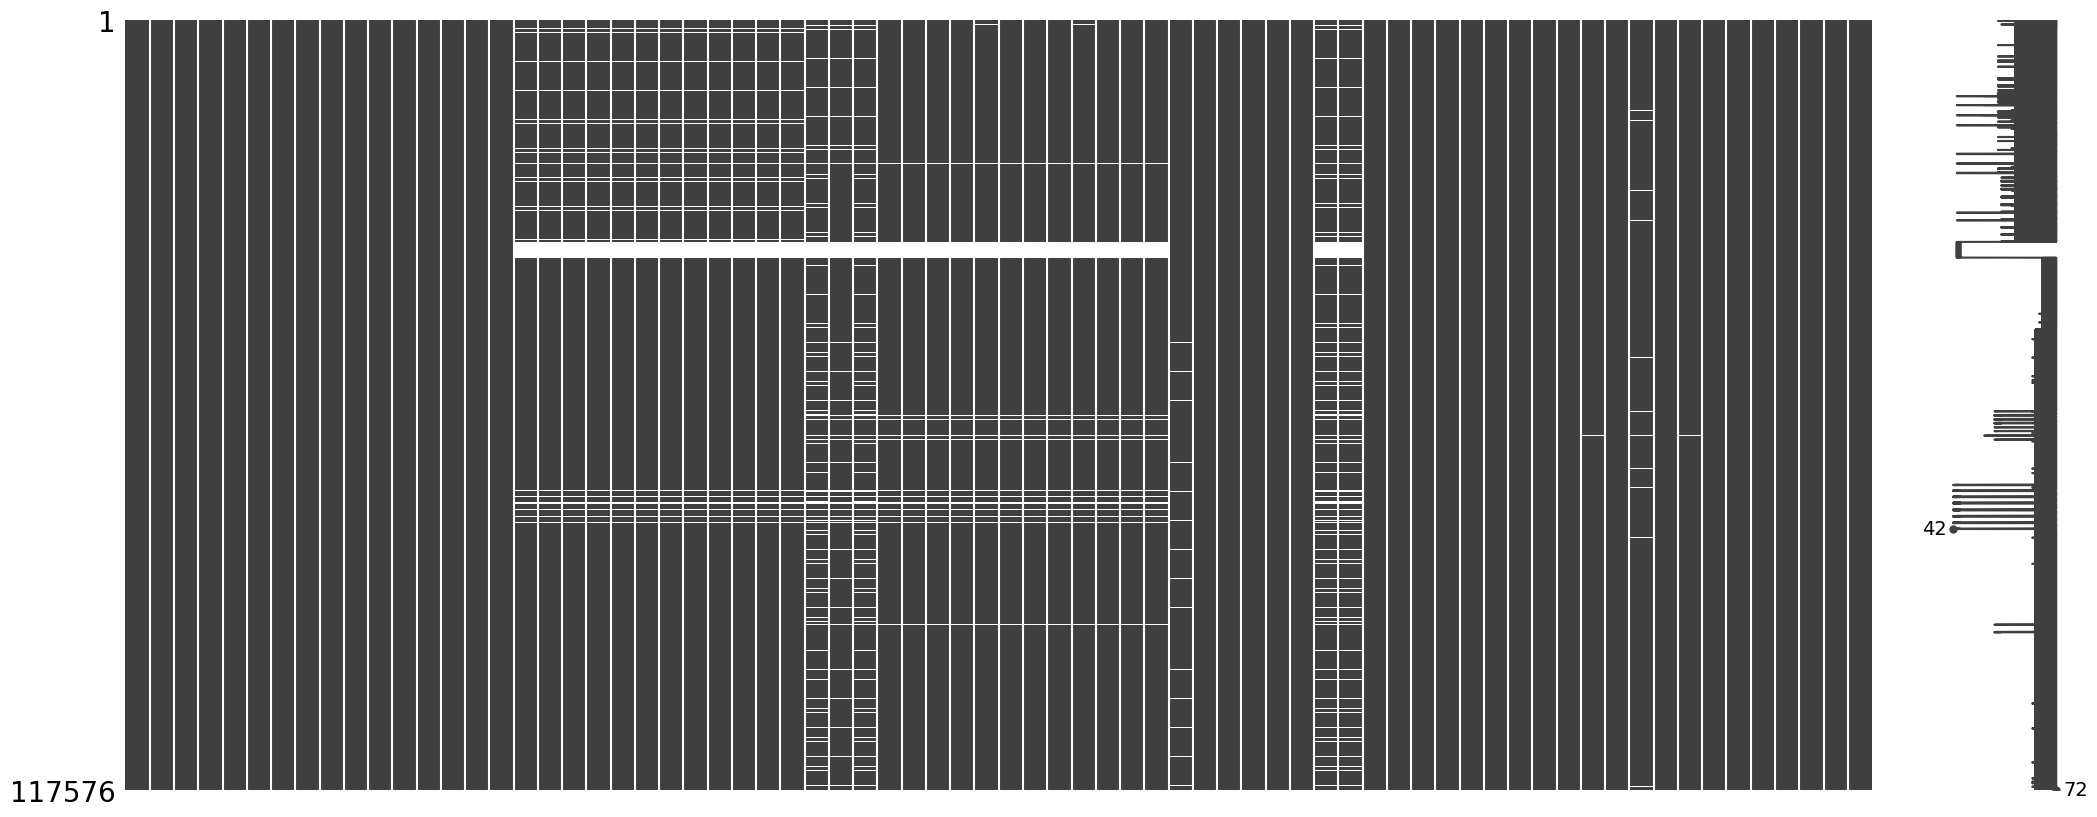

In [84]:
missingno.matrix(merged)

In [85]:
gc.collect()

0

In [86]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

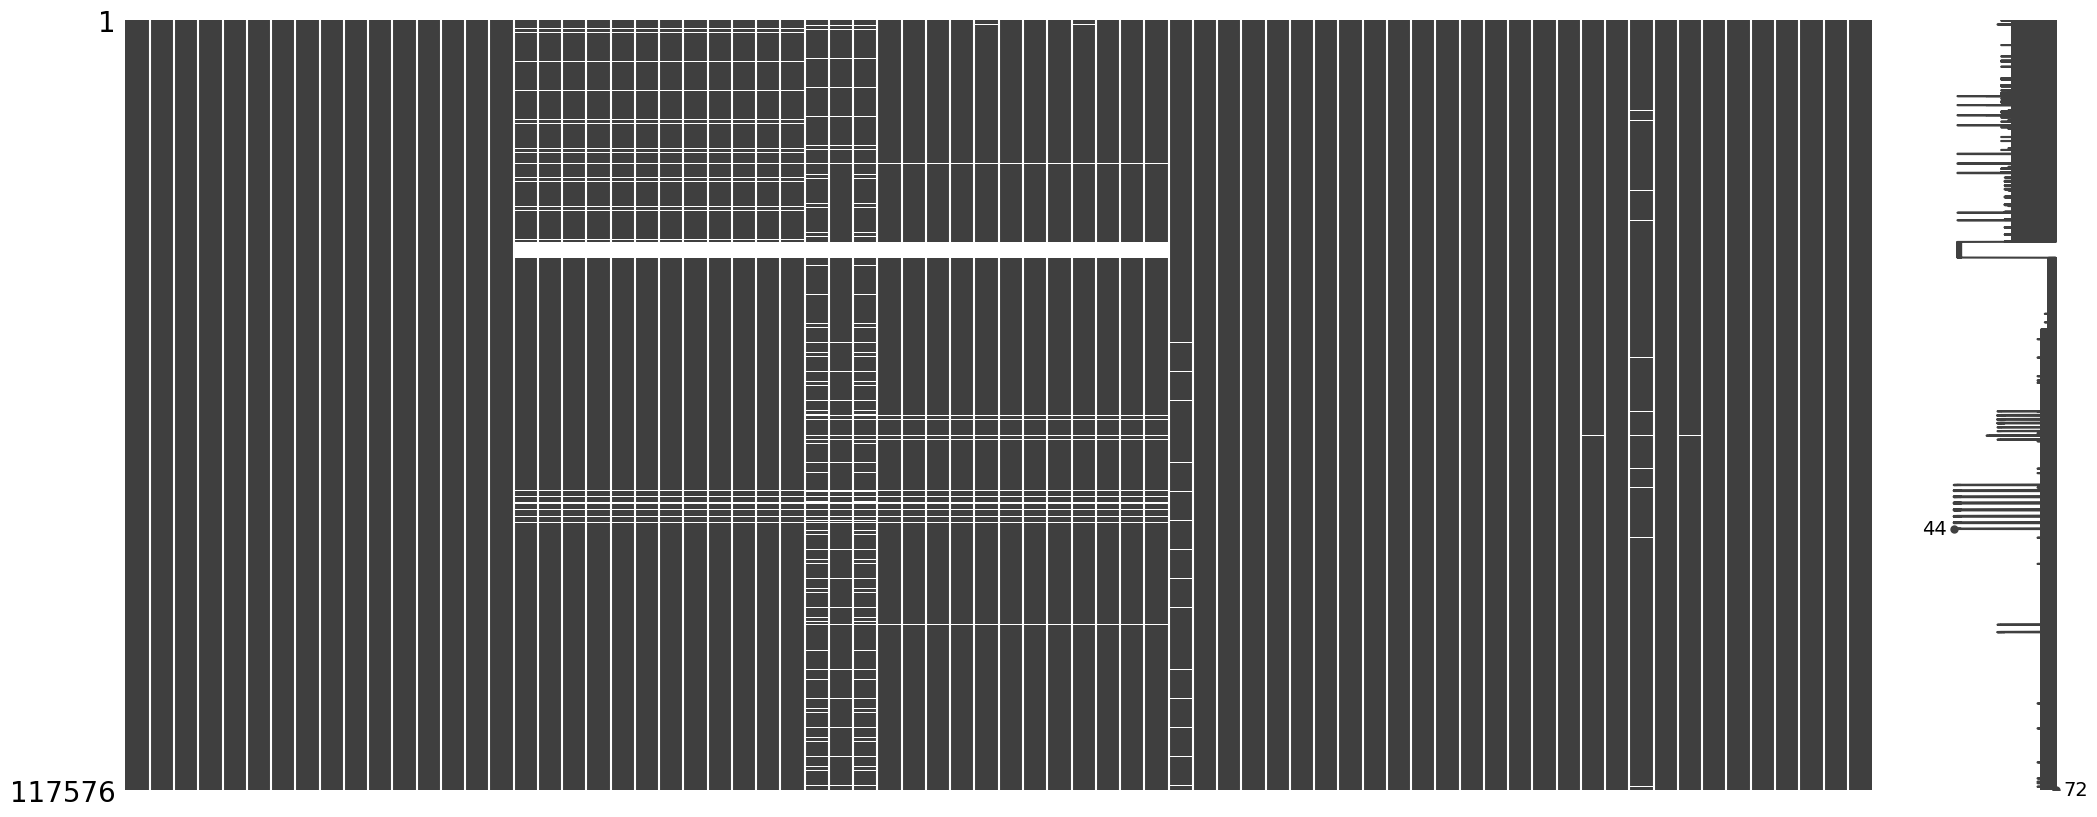

In [87]:
missingno.matrix(merged)

In [88]:
years = merged.year.unique()
years

array([2021, 2022, 2023])

In [90]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3263, 3264, 3265], dtype=int64)

In [91]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [92]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2021,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000
1,1,2021,13.791667,23.750000,44.811321,872.680909,40.000000,-13.000000,53.000000,2.666667,23.166667,23.500000,2.666667,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
2,2,2021,13.250000,26.166667,51.307190,739.625212,39.000000,-12.000000,51.000000,3.500000,20.833333,21.000000,3.500000,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
3,3,2021,11.541667,20.583333,44.746377,816.995141,33.000000,-13.000000,46.000000,0.666667,19.833333,20.500000,0.666667,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
4,4,2021,14.458333,25.083333,44.791667,921.820909,43.000000,-13.000000,56.000000,2.333333,24.333333,24.500000,2.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
5,5,2021,14.125000,23.083333,46.166667,836.150541,38.000000,-12.000000,50.000000,3.500000,22.166667,22.666667,3.500000,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
6,6,2021,12.083333,21.833333,39.696970,898.441411,37.000000,-18.000000,55.000000,0.000000,21.166667,21.833333,0.000000,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,739.000000
7,7,2021,12.208333,20.583333,43.794326,866.670309,35.000000,-12.000000,47.000000,0.833333,20.666667,21.333333,0.833333,1597.000000,365.000000,35.000000,80.111610,736.000000,145.000000,192.000000,736.000000
8,8,2021,14.458333,24.583333,47.275641,889.958715,40.000000,-12.000000,52.000000,2.666667,23.000000,23.833333,2.666667,1597.000000,365.000000,35.000000,80.111610,736.000000,145.000000,192.000000,736.000000
9,9,2021,14.666667,25.500000,45.535714,897.302354,43.000000,-13.000000,56.000000,3.000000,24.000000,24.666667,3.000000,1597.000000,365.000000,35.000000,80.111610,736.000000,145.000000,192.000000,736.000000


In [93]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [94]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19


In [95]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [96]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [97]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [98]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [99]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

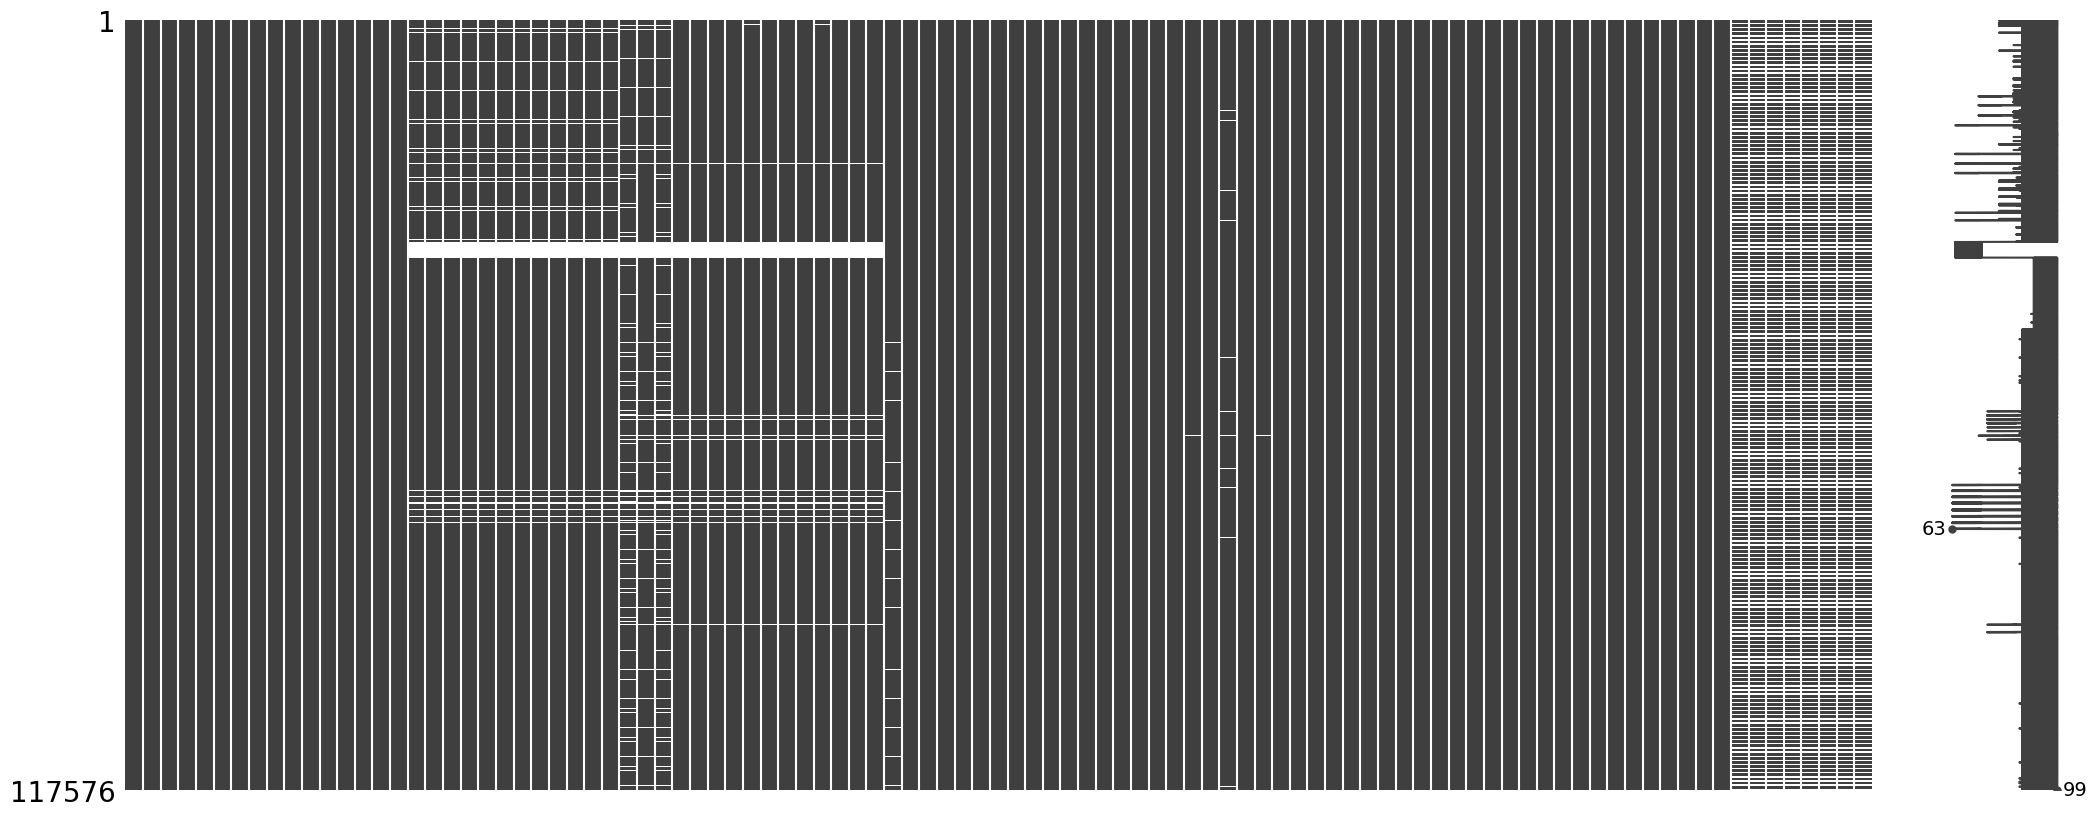

In [100]:
missingno.matrix(dataset)

In [101]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [102]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [103]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [104]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [105]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

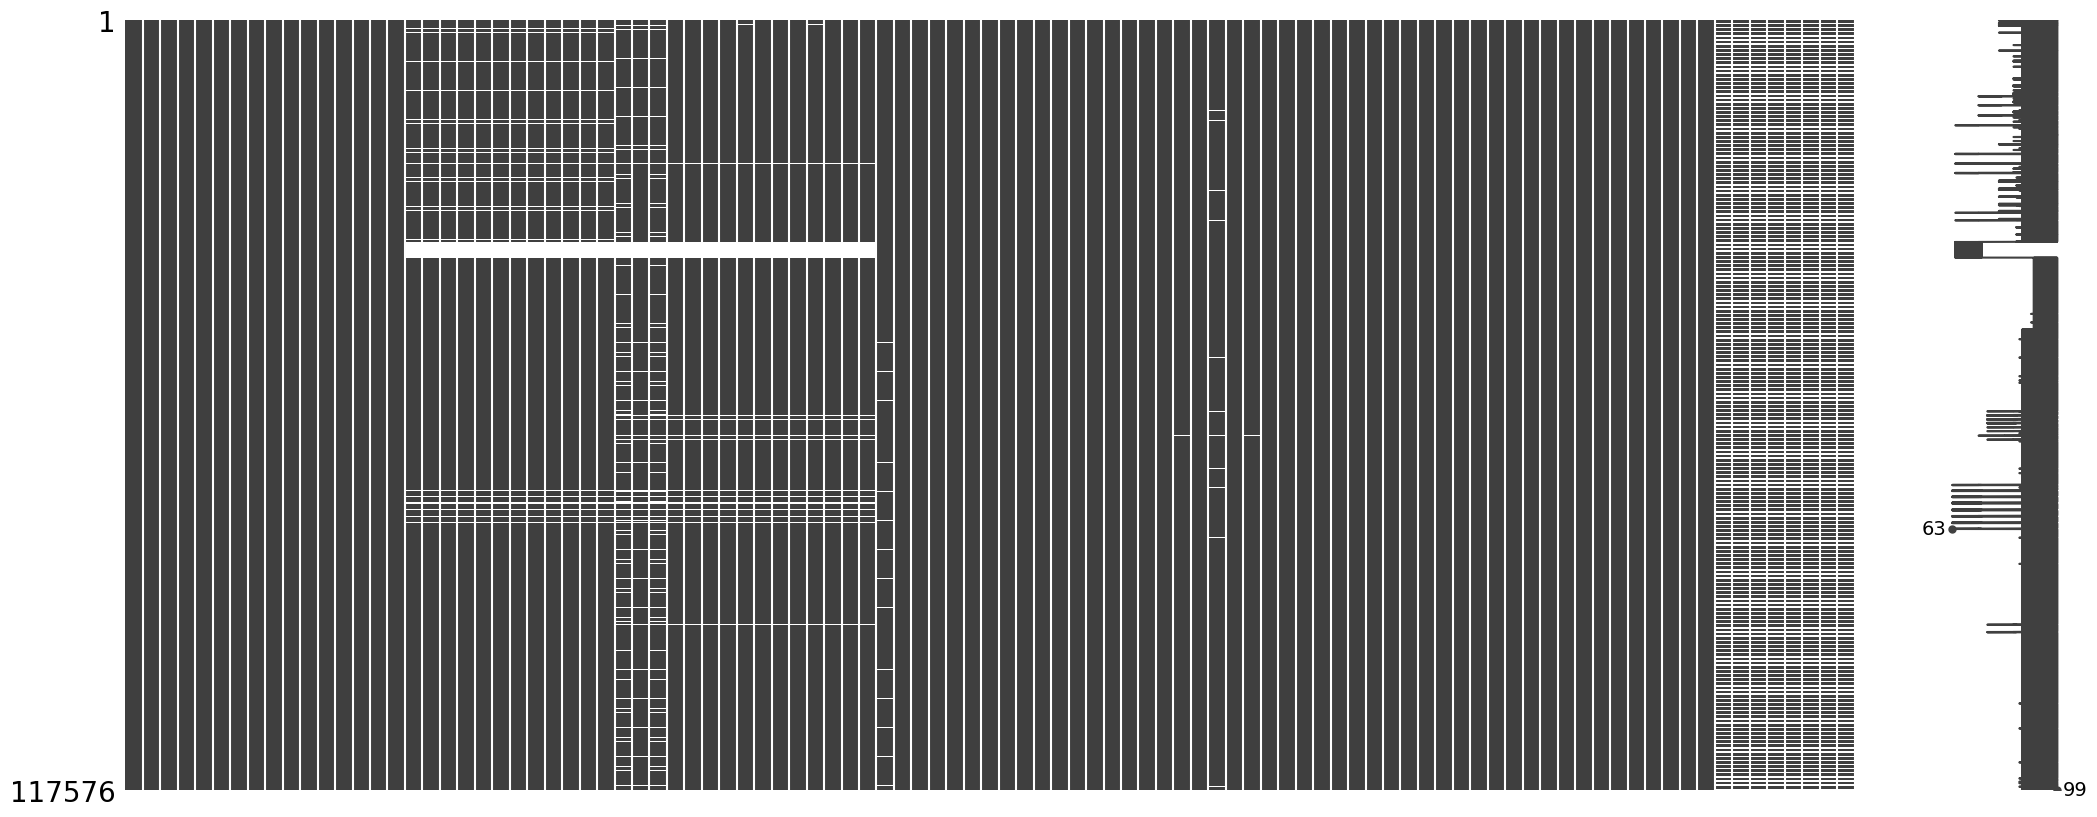

In [106]:
missingno.matrix(dataset)

In [107]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [108]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [109]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [110]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [111]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

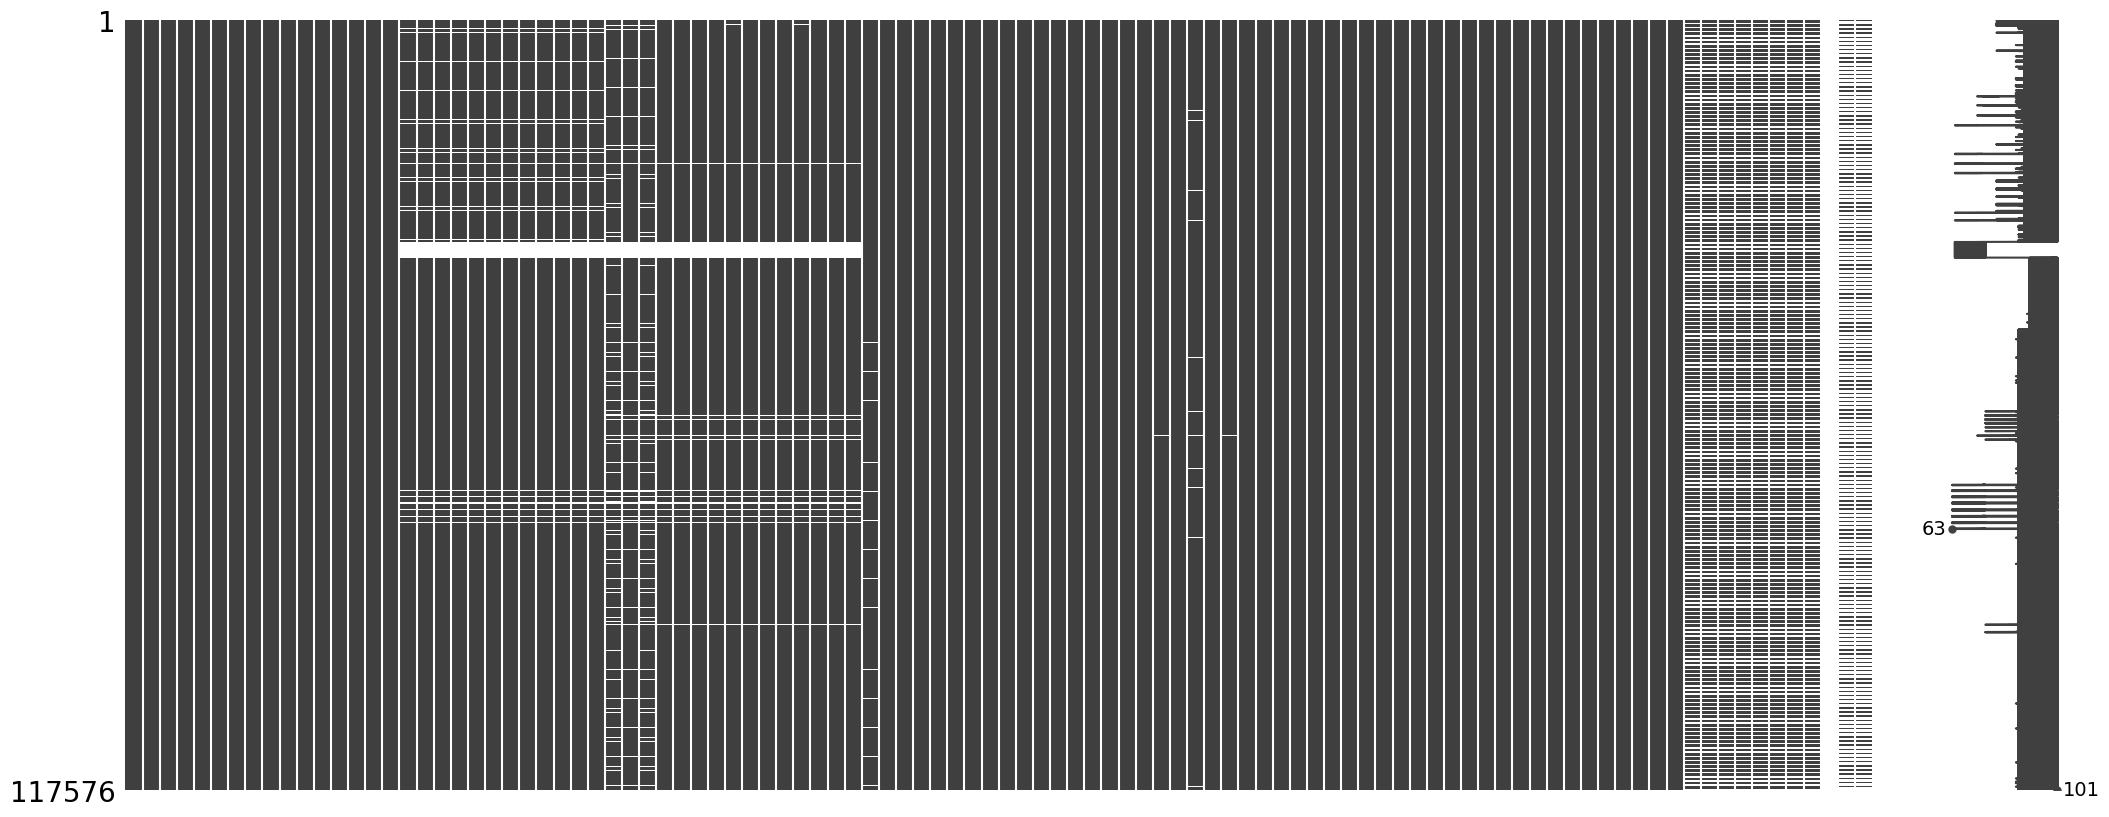

In [112]:
missingno.matrix(dataset)

In [113]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [114]:
missing

,Column,Missing
16,ndvi,5.239200
17,ndmi,5.239200
18,ndwi,5.239200
19,ndbi,5.239200
20,ndvi_mean,4.990800
21,ndmi_mean,4.990800
22,ndwi_mean,4.990800
23,ndbi_mean,4.990800
24,ndvi_std,4.990800
25,ndmi_std,4.990800


In [115]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,352.762657,-11.190000,6.010000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,91.110010,-11.070000,17.310000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,3,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,74.532002,-8.210000,15.250000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,4,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.4777

In [116]:
dataset.reset_index(inplace=True, drop=True)

In [117]:
# dataset['cases'].value_counts()

In [118]:
# dataset['cases'].sum()

In [119]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2021-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.973871,-4.477742,-1.751935,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,11.379441,90.791959,96.575507,352.762657,352.762657,352.762657,-11.190000,6.010000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
1,0,2021-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.232143,0.632143,5.932143,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,3.253929,2.786719,15.602950,138.817181,443.872667,91.110010,-11.070000,17.310000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
2,0,2021-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,3,0.271512,-0.047258,-0.238340,0.047258,0.277165,-0.080598,-0.266065,0.080598,0.034669,0.047009,0.063368,0.047009,11.774516,1.413226,6.593871,0.973871,11.232143,11.774516,15.893333,-4.477742,0.632143,1.413226,3.220000,-1.751935,5.932143,6.593871,9.556667,2.404258,0.837226,46.593086,74.532002,518.404669,74.532002,-8.210000,15.250000,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.000000,4.925067,14,99.000000,10,99.000000,10,99.000000,4,4,6,4,4,2,0,12.333333,19.833333,45.075758,835.391398,33.000000,-11.000000,44.000000,1.333333,20.666667,21.000000,1.333333,1582.000000,352.000000,32.000000,82.148290,739.000000,138.000000,174.000000,517.000000,6329.000000,29205.000000,10793.000000,46327.000000,6016.000000,29717.000000,14073.000000,49806.000000,NaN,4290.000000,3604.000000
3,0,2021-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.658820,41.335420,2,2,2,2021,4,0.267305,-0.085639,-0.263355,0.085639,0.267850,-0.112015,-0.273936,0.112015,0.026953,0.029501,0.046660,0.029501,15.893333,3.220000,9.556667,0.973871,11.232143,11.774516,15.893333,-4.4777

In [120]:
cols = dataset.columns

In [121]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [122]:
len(cols)

102

In [123]:
years = dataset.year.unique().tolist()

In [124]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)